In [1]:
# general-use imports
import numpy as np
import pandas as pd
import pickle
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
import arviz as az

# custom imports
from settings import ROOT_DIR
from nteprsm import utils
from nteprsm.constants import NTEP_COLOR_SCALE
import rutils
rutils.set_custom_template()
NTEP_COLOR_SCALE_list = list(NTEP_COLOR_SCALE.values())

/users/2/oboiko/.conda/envs/nteprsm_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the data for visualizations 

In [2]:
# modify file paths as needed
file_path = ROOT_DIR/'kb2017/nj2/quality.csv'
fit_object_path = ROOT_DIR/'model_runs/seasonality_nj2_quality/fit_seasonality_nj2_quality.pkl'
fit_object_path_old = ROOT_DIR/'model_runs/spatial_nj2_quality/fit_spatial_nj2_quality.pkl'

# load raw data
datahandler = utils.DataHandler(filepath=file_path)
datahandler.preprocess_data()
datahandler.generate_stan_data()
# load fit object from a previously trained model
with open(fit_object_path, 'rb') as file:
    fit = pickle.load(file)
# load fit object from a previously trained OLD (SPATIAL) model
with open(fit_object_path_old, 'rb') as file:
    fit_old_model = pickle.load(file)

2025-07-18 10:46:39,483 - NtepRsm - INFO - Raw data successfully loaded.
/users/2/oboiko/NTEP/nteprsm/nteprsm/utils.py:244: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")
2025-07-18 10:46:39,541 - NtepRsm - INFO - Preprocessing complete. Model data ready.
2025-07-18 10:46:39,549 - NtepRsm - INFO - Stan data dictionary created.


## Histogram of raw ratings distribution

In [3]:
# prepare data
model_data = datahandler.model_data
rater_mapping = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G'}
model_data['rater_display_code'] = model_data['rater_code'].map(rater_mapping)
model_data['value_original'] = model_data['value']+1

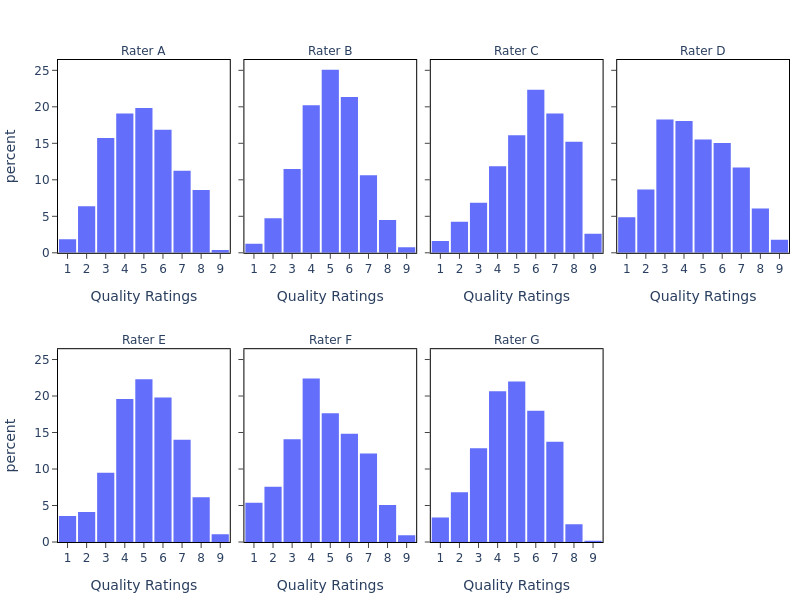

In [4]:
# make a figure
fig = px.histogram(
    model_data, 
    x='value_original', 
    facet_col='rater_display_code', 
    facet_col_wrap=4,
    facet_row_spacing=0.2,
    histnorm='percent',
    nbins=10,
    category_orders = {
        'rater_display_code': rater_mapping.values()
    }
)
fig.for_each_annotation(lambda a: a.update(text='Rater ' + a.text.split('=')[-1]))
fig.update_xaxes(
    tickmode='array',
    showticklabels=True,
    tickvals=list(range(0,10)),
    title='Quality Ratings'
)
fig.update_layout(bargap=0.1, margin=dict(l=10, r=10, b=10, t=60))

# adjust figure size here for static renderer for plotly
# for interactive plot adjust figure size inside `update_layout`
pio.kaleido.scope.default_width = 800
pio.kaleido.scope.default_height = 600
fig.show(renderer='png') # change to renderer="iframe" for interactive plot
#fig.write_image('figures/fig_raw_data_hist.png')

## Spatial effect comparison

In [5]:
# prepare data
grouped = datahandler.model_data.groupby('plot_id')[['row', 'col']].mean()
hmap_y = grouped['row']
hmap_x = grouped['col']
plot_effect_means = fit.plot_effect.mean(axis = 0)
plot_effect_means_old_model = fit_old_model.plot_effect.mean(axis = 0)

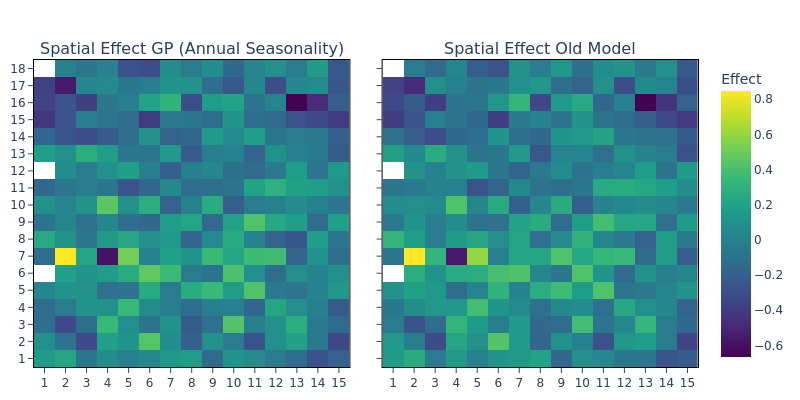

In [6]:
# make a figure
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Spatial Effect GP (Annual Seasonality)', 'Spatial Effect Old Model'],
    shared_yaxes=True,
    horizontal_spacing=0.05
)

fig.add_trace(go.Heatmap(
    z=plot_effect_means, x=hmap_x, y=hmap_y,
    colorscale='viridis', colorbar=dict(title='Effect')
), row=1, col=1)

fig.add_trace(go.Heatmap(
    z=plot_effect_means_old_model, x=hmap_x, y=hmap_y,
    colorscale='viridis', showscale=False
), row=1, col=2)

fig.update_xaxes(tickmode='array', tickvals=hmap_x, ticktext=hmap_x)
fig.update_yaxes(tickmode='array', tickvals=hmap_y, ticktext=hmap_y, autorange=True)
fig.update_layout(
    margin=dict(l=10, r=10, b=10, t=60)
)

# adjust figure size here for static renderer for plotly
pio.kaleido.scope.default_width = 800
pio.kaleido.scope.default_height = 400
fig.show(renderer='png') # change to renderer="iframe" for interactive plot
#fig.write_image('figures/fig_spatial_effect_comp.png')

## Seasonality Curves

In [7]:
# prepare data/labels
name2code = rutils.map_name2code(datahandler, 'entry_name', 'entry_code', invert=True)
print(name2code)

{75: 'A-15-6', 76: 'A-16-17', 73: 'A-16-2', 78: 'A06-8', 71: 'A10-280', 67: 'A11-26', 69: 'A11-38', 1: 'A11-40', 66: 'A12-34', 2: 'A13-1', 64: 'A16-1', 65: 'A16-7', 3: 'A99-2897', 9: 'AKB3128', 10: 'AKB3179', 11: 'AKB3241', 70: 'Acoustic PPG-KB 1131', 15: 'After Midnight', 38: 'Amaze', 42: 'Aviator II', 20: 'BAR PP 71213', 25: 'BAR PP 7236V', 21: 'BAR PP 7309V', 22: 'BAR PP 79366', 26: 'BAR PP 79494', 24: 'BAR PP 7K426', 8: 'Babe', 27: 'Barserati', 23: 'Barvette HGT', 44: 'Blue Devil', 32: 'Blue Gem', 5: 'Blue Knight', 46: 'Bombay', 48: 'Cloud', 39: 'Comanche', 49: 'DLFPS-340/3364', 55: 'DLFPS-340/3438', 58: 'DLFPS-340/3444', 50: 'DLFPS-340/3446', 59: 'DLFPS-340/3455', 53: 'DLFPS-340/3494', 54: 'DLFPS-340/3500', 57: 'DLFPS-340/3548', 56: 'DLFPS-340/3549', 60: 'DLFPS-340/3550', 61: 'DLFPS-340/3551', 62: 'DLFPS-340/3552', 52: 'DLFPS-340/3553', 51: 'DLFPS-340/3556', 83: 'Dublin', 82: 'Electric', 40: 'Finish Line', 41: 'Heartland', 16: 'J-1138', 17: 'J-1319', 18: 'J-2726', 29: 'Jersey', 13

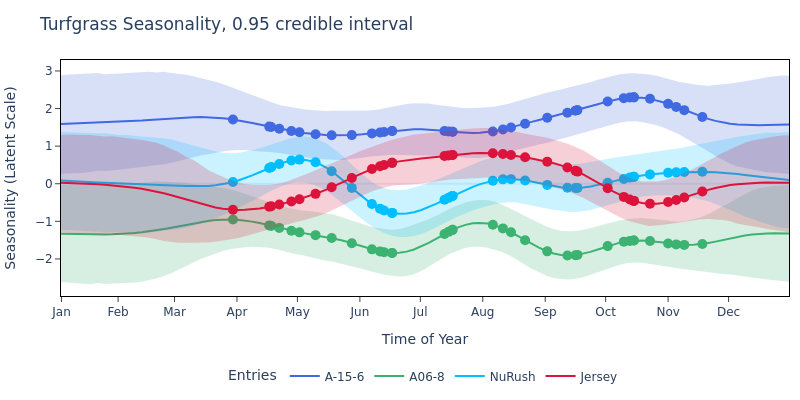

In [8]:
# change entry codes to visualize other varieties
entries = [7, 19, 29, 56]
entries = [75, 78, 19, 29]
colors = ['royalblue', 'mediumseagreen', 'deepskyblue', 'crimson']
## params
ci = 0.95  # Credible interval

# make a figure
fig = go.Figure()

# time_effect_data_points
data_points = rutils.extract_time_effect(datahandler, fit)
data_points_time = data_points.index.values

for i, entry in enumerate(entries):
    entry_name = name2code[entry]
    legend_group = f'Entry {entry_name}'    
    samples = fit.pred_time_effect[:, entry, :]  # Shape: (n_samples, n_time_points)
    
    # Compute statistics
    time_points = np.arange(samples.shape[1])+1  # Time indices
    mean_values = np.mean(samples, axis=0)  # Mean over samples
    lower_bound = np.percentile(samples, 100 * (1 - ci) / 2, axis=0)  # 2.5th percentile
    upper_bound = np.percentile(samples, 100 * (ci + (1 - ci) / 2), axis=0)  # 97.5th percentile

    # Add data point
    fig.add_trace(go.Scatter(
        x=data_points_time*100, y=data_points[entry],
        mode='markers',
        marker=dict(
            symbol='circle',  # Set the marker shape to "X"
            color=colors[i],  # Keep the color
            size=10  # Optionally, set the size of the marker
        ),
        name=f'{entry_name} Mean',
        legendgroup=legend_group,
        showlegend=False,
    ))

    # Add mean line
    fig.add_trace(go.Scatter(
        x=time_points, y=mean_values,
        mode='lines',
        line=dict(color=colors[i], width=2),
        name=f'{entry_name}',
        legendgroup=legend_group,
    ))
    
    # Add 95% Credible Interval (Shaded Region)
    fig.add_trace(go.Scatter(
        x=time_points.tolist() + time_points[::-1].tolist(),
        y=upper_bound.tolist() + lower_bound[::-1].tolist(),
        fill='toself',
        fillcolor=colors[i],
        opacity=0.2,
        line=dict(color='rgba(255,255,255,0)'),
        name=f'{entry_name} 95% CI',
        legendgroup=legend_group,  # Grouping
        showlegend=False,
    ))
    
# Compute correct tick positions based on actual day of the year
days_in_month = np.array([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])  # Non-leap year
cumulative_days = np.cumsum(days_in_month)+1  # Cumulative sum to get end of each month
month_positions = 100*cumulative_days / 365  # Normalize to range 0-100
month_positions[0] += 0.8

# Generate month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=month_positions,  # Correctly spaced tick positions
        ticktext=month_labels,  # Month names
        title='Time of Year'
    ),
    yaxis_title='Seasonality (Latent Scale)',
    title=f'Turfgrass Seasonality, {ci} credible interval',
    legend=dict(
        title='Entries',
        orientation='h',
        yanchor='bottom',
        y=-0.4,
        xanchor='center',
        x=0.5
    ),
    margin=dict(l=10, r=10, b=10, t=60)
    
) 

# adjust figure size here for static renderer for plotly
pio.kaleido.scope.default_width = 800
pio.kaleido.scope.default_height = 400
fig.show(renderer='png') # change to renderer="iframe" for interactive plot
#fig.write_image('figures/fig_seasonality_curves.png')

## Category Characteristic Curves

In [9]:
def plot_rater_characteristic_curve(
        betas,
        min_theta=-6,
        max_theta=6,
        resolution=500,
        colors=px.colors.diverging.BrBG,
        dimensions=None,
    ) -> go.Figure:
        """
        Plot the characteristic curves for raters based on the fitted Stan model.

        Args:
            rater_id (int, optional): The rater ID to plot. If None, all raters
                will be plotted. Defaults to None.
            dimensions (tuple, optional): Dimensions of the plot as (width, height).

        Returns:
            A Plotly figure object containing the plotted characteristic curves.
        """
        betas_with_bounds = np.concatenate(([min_theta], betas, [max_theta]))
        x = np.linspace(min_theta, max_theta, int((max_theta - min_theta) * resolution))
        num_categories = len(betas) + 1
        fig = go.Figure()
        fig.update_layout(
            xaxis_title='Turf Quality on Latent Scale',
            yaxis_title='Probability',
            legend=dict(x=1.02, y=1),
        )
        for i in range(num_categories):
            fig.add_trace(
                go.Scatter(
                    x=x,
                    y=[rutils.rsm_probability(i, theta, betas) for theta in x],
                    line=dict(width=2, color=colors[i]),
                    name=str(i + 1),
                )
            )
            fig.add_shape(
                type='rect',
                x0=betas_with_bounds[i],
                x1=betas_with_bounds[i + 1],
                y0=1.02,
                y1=1.1,
                fillcolor=colors[i],
            )
            if i != num_categories - 1:
                fig.add_shape(
                    type='line',
                    x0=betas[i],
                    x1=betas[i],
                    y0=0,
                    y1=1,
                    line=dict(color=colors[i], dash='dot'),
                )
        if dimensions:
            fig.update_layout(width=dimensions[0], height=dimensions[1])
        return fig

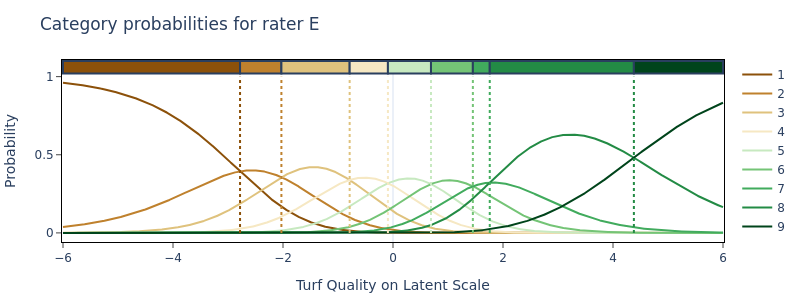

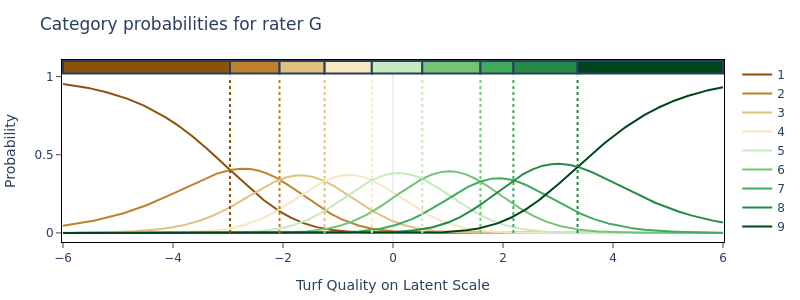

In [10]:
rater_list = ['E', 'G']
for i in range(len(rater_list)):
    # make a figure
    fig = plot_rater_characteristic_curve(fit.tau_rater.mean(axis=0)[i,:], colors=NTEP_COLOR_SCALE_list)
    fig.update_layout(
        title=f'Category probabilities for rater {rater_list[i]}',
        margin=dict(l=10, r=10, b=10, t=60)
    )
    # adjust figure size here for static renderer for plotly
    pio.kaleido.scope.default_width = 800
    pio.kaleido.scope.default_height = 300
    fig.show(renderer='png') # change to renderer="iframe" for interactive plot
    #fig.write_image(f'figures/fig_cat_prob_{rater_list[i]}.png')

## Most probable rating outcomes

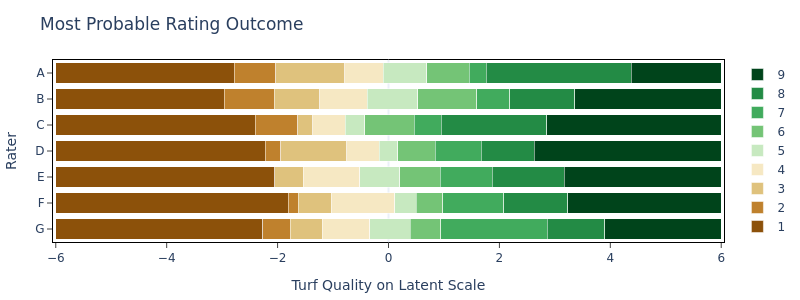

In [11]:
rater_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
thresholds = [fit.tau_rater.mean(axis=0)[i,:] for i in range(7)]
x_start, x_end = -6, 6

# make a figure
fig = go.Figure()

for i, (rater, rater_thresholds) in enumerate(zip(rater_list, thresholds)):
    # Add the start and end points for categories
    rater_thresholds = [x_start] + list(rater_thresholds) + [x_end]
    
    for j in range(len(rater_thresholds) - 1):
        # Add a rectangle for each category
        fig.add_trace(go.Bar(
            x=[rater_thresholds[j + 1] - rater_thresholds[j]],  # Width of the bar
            y=[rater],
            orientation='h',
            marker=dict(color=NTEP_COLOR_SCALE_list[j % len(NTEP_COLOR_SCALE_list)]),
            name=f"{j + 1}" if i == 0 else None,  # Show legend only for the first rater
            showlegend=(i == 0),  # Show legend only once
            base=rater_thresholds[j]
        ))

fig.update_yaxes(autorange='reversed')
fig.update_layout(
    barmode='stack',
    title='Most Probable Rating Outcome',
    xaxis=dict(title='Turf Quality on Latent Scale', range=[x_start-0.05, x_end+0.05]),
    yaxis=dict(title='Rater', categoryorder='category ascending'),
    showlegend=True,
    margin=dict(l=10, r=10, b=10, t=60),
)

# adjust figure size here for static renderer for plotly
pio.kaleido.scope.default_width = 800
pio.kaleido.scope.default_height = 300
fig.show(renderer='png') # change to renderer="iframe" for interactive plot
#fig.write_image(f'figures/fig_probable_outcome.png')

## ELPD comparison

In [12]:
azdata = az.from_cmdstanpy(fit)
azdata_old = az.from_cmdstanpy(fit_old_model)

In [13]:
%%time
az.loo(azdata)

CPU times: user 18.9 s, sys: 145 ms, total: 19 s
Wall time: 19.1 s


Computed from 6000 posterior samples and 9603 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -15095.26    72.25
p_loo      767.09        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     9603  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [14]:
#%%time
#az.loo(azdata_old)